<a href="https://colab.research.google.com/github/LeonBarros/LeonBarros/blob/main/Estudo_de_Ci%C3%AAncia_de_Dados_%26_Redes_Neurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assunto: Estudando Long Short-Term Memory (LSTM)

Objetivo: Estudar Sobre Análise de Dados Utilizando Redes Neurais.

Topicos Estudados: Comportamento, bibliotecas, Propriedades Aplicada em Séries Temporais.

In [ ]:
# Anotações Base

# A base do comportamento dessa rede neural são as portas (gates) que controlam o fluxo de informação ao longo do tempo.
# As principais portas são as de entrada, saída e de esquecimento.

## O Comportamento e a Matemática Aplicada Por Trás de Cada Porta

**Porta de Entrada**

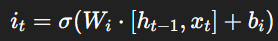

In [ ]:
# Interpretação: Ela decide quanto da nova informação deve ser armazenada na memória.

# Entendendo a Formúla

# 𝜎 - sigmoide, cada componente de "It" indica o peso importância de cada valor novo.
# Wf - uma matriz de pesos (Define o quanto confiar nas novas informações)
# [ht−1,xt] - concatenação de vetores (Junta a saída do tempo anterior com a entrada atual)
# bf - vetor de viés (Soma um deslocamento ao resultado que foi obtido)

**Porta de Saída**

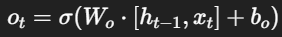

In [ ]:
# Interpretação: Ela decide quanto da memória interna será usada para produzir a saída atual.

# Entendendo a Formúla

# 𝜎 - saída entre 0 e 1 ou seja o peso aplicado à saída total.
# Wo - Pesos, que decidem quanto da memória será usada como saída.
# [ht−1,xt] - Mesmo padrão de concatenação
# bo - Mesmo vetor de viés

**Porta de Esquecimento**

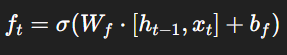

In [ ]:
# Interpretação: Ela é uma porta lógica (com saída entre 0 e 1) que decide quanto da memória antiga deve ser esquecida.

# Entendendo a Formúla

# 𝜎 - função sigmoide logistica (controla a “visibilidade” da célula)
# Wf - uma matriz para os pesos da porta de esquecimento
# [ht−1,xt] - Mesmo padrão de concatenação
# bf - Mesmo vetor de viés

## Bibliotecas e Aplicações

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install keras # Para construção e treinamento do modelo LSTM.
!pip install scikit-learn # Para pré-processamento de dados, como normalização e divisão de conjuntos de dados.
!pip install yfinance

In [ ]:
# Levantamento de Dados

import yfinance as yf

df = yf.download("MSFT", start="1983-05-13", end="2025-01-01")

df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400
...,...,...,...,...,...
2024-12-24,437.647400,437.916385,432.527101,432.985331,7164500
2024-12-26,436.432068,439.251246,434.957756,437.398354,8194200


In [ ]:
df.reset_index(inplace=True) #resetei o index da tabela para evitar erros

df_selected = df[['Date', 'Close']]
df_selected

Price,Date,Close
Ticker,,MSFT
0,1986-03-13,0.059598
1,1986-03-14,0.061726
2,1986-03-17,0.062791
3,1986-03-18,0.061194
4,1986-03-19,0.060130
...,...,...
9774,2024-12-24,437.647400
9775,2024-12-26,436.432068
9776,2024-12-27,428.881104


In [ ]:
df['Date'] # Organizei em uma coluna

,Date
0,1986-03-13
1,1986-03-14
2,1986-03-17
3,1986-03-18
4,1986-03-19
...,...
9774,2024-12-24
9775,2024-12-26
9776,2024-12-27
9777,2024-12-30


In [ ]:
# Manipulando da String para Facilitar Depois no Processo de Criação de RN

import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [ ]:
df # Exibindo o DataFrame Formatado

Price,Date,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT
0,1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1,1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
2,1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
3,1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
4,1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400
...,...,...,...,...,...,...
9774,2024-12-24,437.647400,437.916385,432.527101,432.985331,7164500
9775,2024-12-26,436.432068,439.251246,434.957756,437.398354,8194200
9776,2024-12-27,428.881104,433.553144,424.717120,432.935523,18117700


In [ ]:
df.index = df.pop('Date')      # Removendo a Coluna Data do DataFrame
df

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400
...,...,...,...,...,...
2024-12-24,437.647400,437.916385,432.527101,432.985331,7164500
2024-12-26,436.432068,439.251246,434.957756,437.398354,8194200


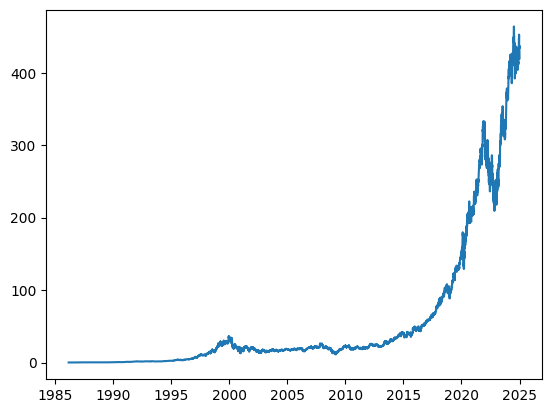

In [ ]:
# Plotando o Dataframe com Matplot

import matplotlib.pyplot as plt

plt.plot(df.index, df['Close'])

In [ ]:
# Convertendo a Série Temporal em uma Estrutura Adequada para Treinamento de ML

import numpy as np
import pandas as pd

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date

  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)

    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
    next_date_str = next_datetime_str.split('T')[0]
    year_month_day = next_date_str.split('-')
    year, month, day = year_month_day
    next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))

    if last_time:
      break

    target_date = next_date

    if target_date == last_date:
      last_time = True

  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]

  ret_df['Target'] = Y

  return ret_df

# Janela Temporal a ser explorada no segundo momento: '2021-03-25 até 2023-04-24'
windowed_df = df_to_windowed_df(df,
                                '2021-03-25',
                                '2023-04-24',
                                n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2021-03-25,227.761932,229.296463,227.250397,[224.2391815185547]
1,2021-03-26,229.296463,227.250397,224.239182,[228.23480224609375]
2,2021-03-29,227.250397,224.239182,228.234802,[227.03807067871094]
3,2021-03-30,224.239182,228.234802,227.038071,[223.76626586914062]
4,2021-03-31,228.234802,227.038071,223.766266,[227.54959106445312]
...,...,...,...,...,...
519,2023-04-18,284.779510,281.144196,283.757721,[283.335205078125]
520,2023-04-19,281.144196,283.757721,283.335205,[283.4138488769531]
521,2023-04-20,283.757721,283.335205,283.413849,[281.1146545410156]
522,2023-04-21,283.335205,283.413849,281.114655,[280.7708435058594]


In [ ]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

<ipython-input-28-e0b121546ba7>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return dates, X.astype(np.float32), Y.astype(np.float32)


((524,), (524, 3, 1), (524,))

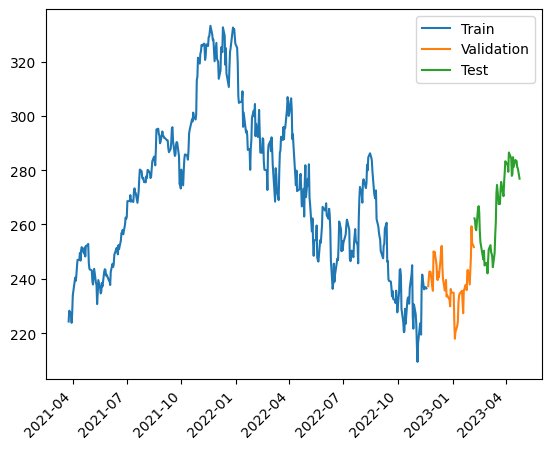

In [ ]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.xticks(rotation=45, ha='right')

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [ ]:
input("insira a tecla para continuar":)

def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

date = df_as_np[:, 0]
middle_matriz = df_as_np[:, 1: -1]

X = middle_matriz.reshape((len(date), middle_matriz.shape[1], 1))

y = df_as_np[:, -1]

return date, X.astype(np)